In [10]:
import numpy as np
import matplotlib.pyplot as plt

from numpy import poly1d, polyfit


In [11]:
data = np.loadtxt("model_penergy.out")

<>:104: SyntaxWarning: invalid escape sequence '\p'
<>:104: SyntaxWarning: invalid escape sequence '\A'
<>:159: SyntaxWarning: invalid escape sequence '\A'
<>:104: SyntaxWarning: invalid escape sequence '\p'
<>:104: SyntaxWarning: invalid escape sequence '\A'
<>:159: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_127300/1002156472.py:104: SyntaxWarning: invalid escape sequence '\p'
  label=f"Experimental: {experimental:.4f} $\pm$ {experimental_uncertainty:.4f} $\AA$",
/tmp/ipykernel_127300/1002156472.py:104: SyntaxWarning: invalid escape sequence '\A'
  label=f"Experimental: {experimental:.4f} $\pm$ {experimental_uncertainty:.4f} $\AA$",
/tmp/ipykernel_127300/1002156472.py:159: SyntaxWarning: invalid escape sequence '\A'
  ax.set_xlabel("Nearest Neighbor Distance ($\AA$)")


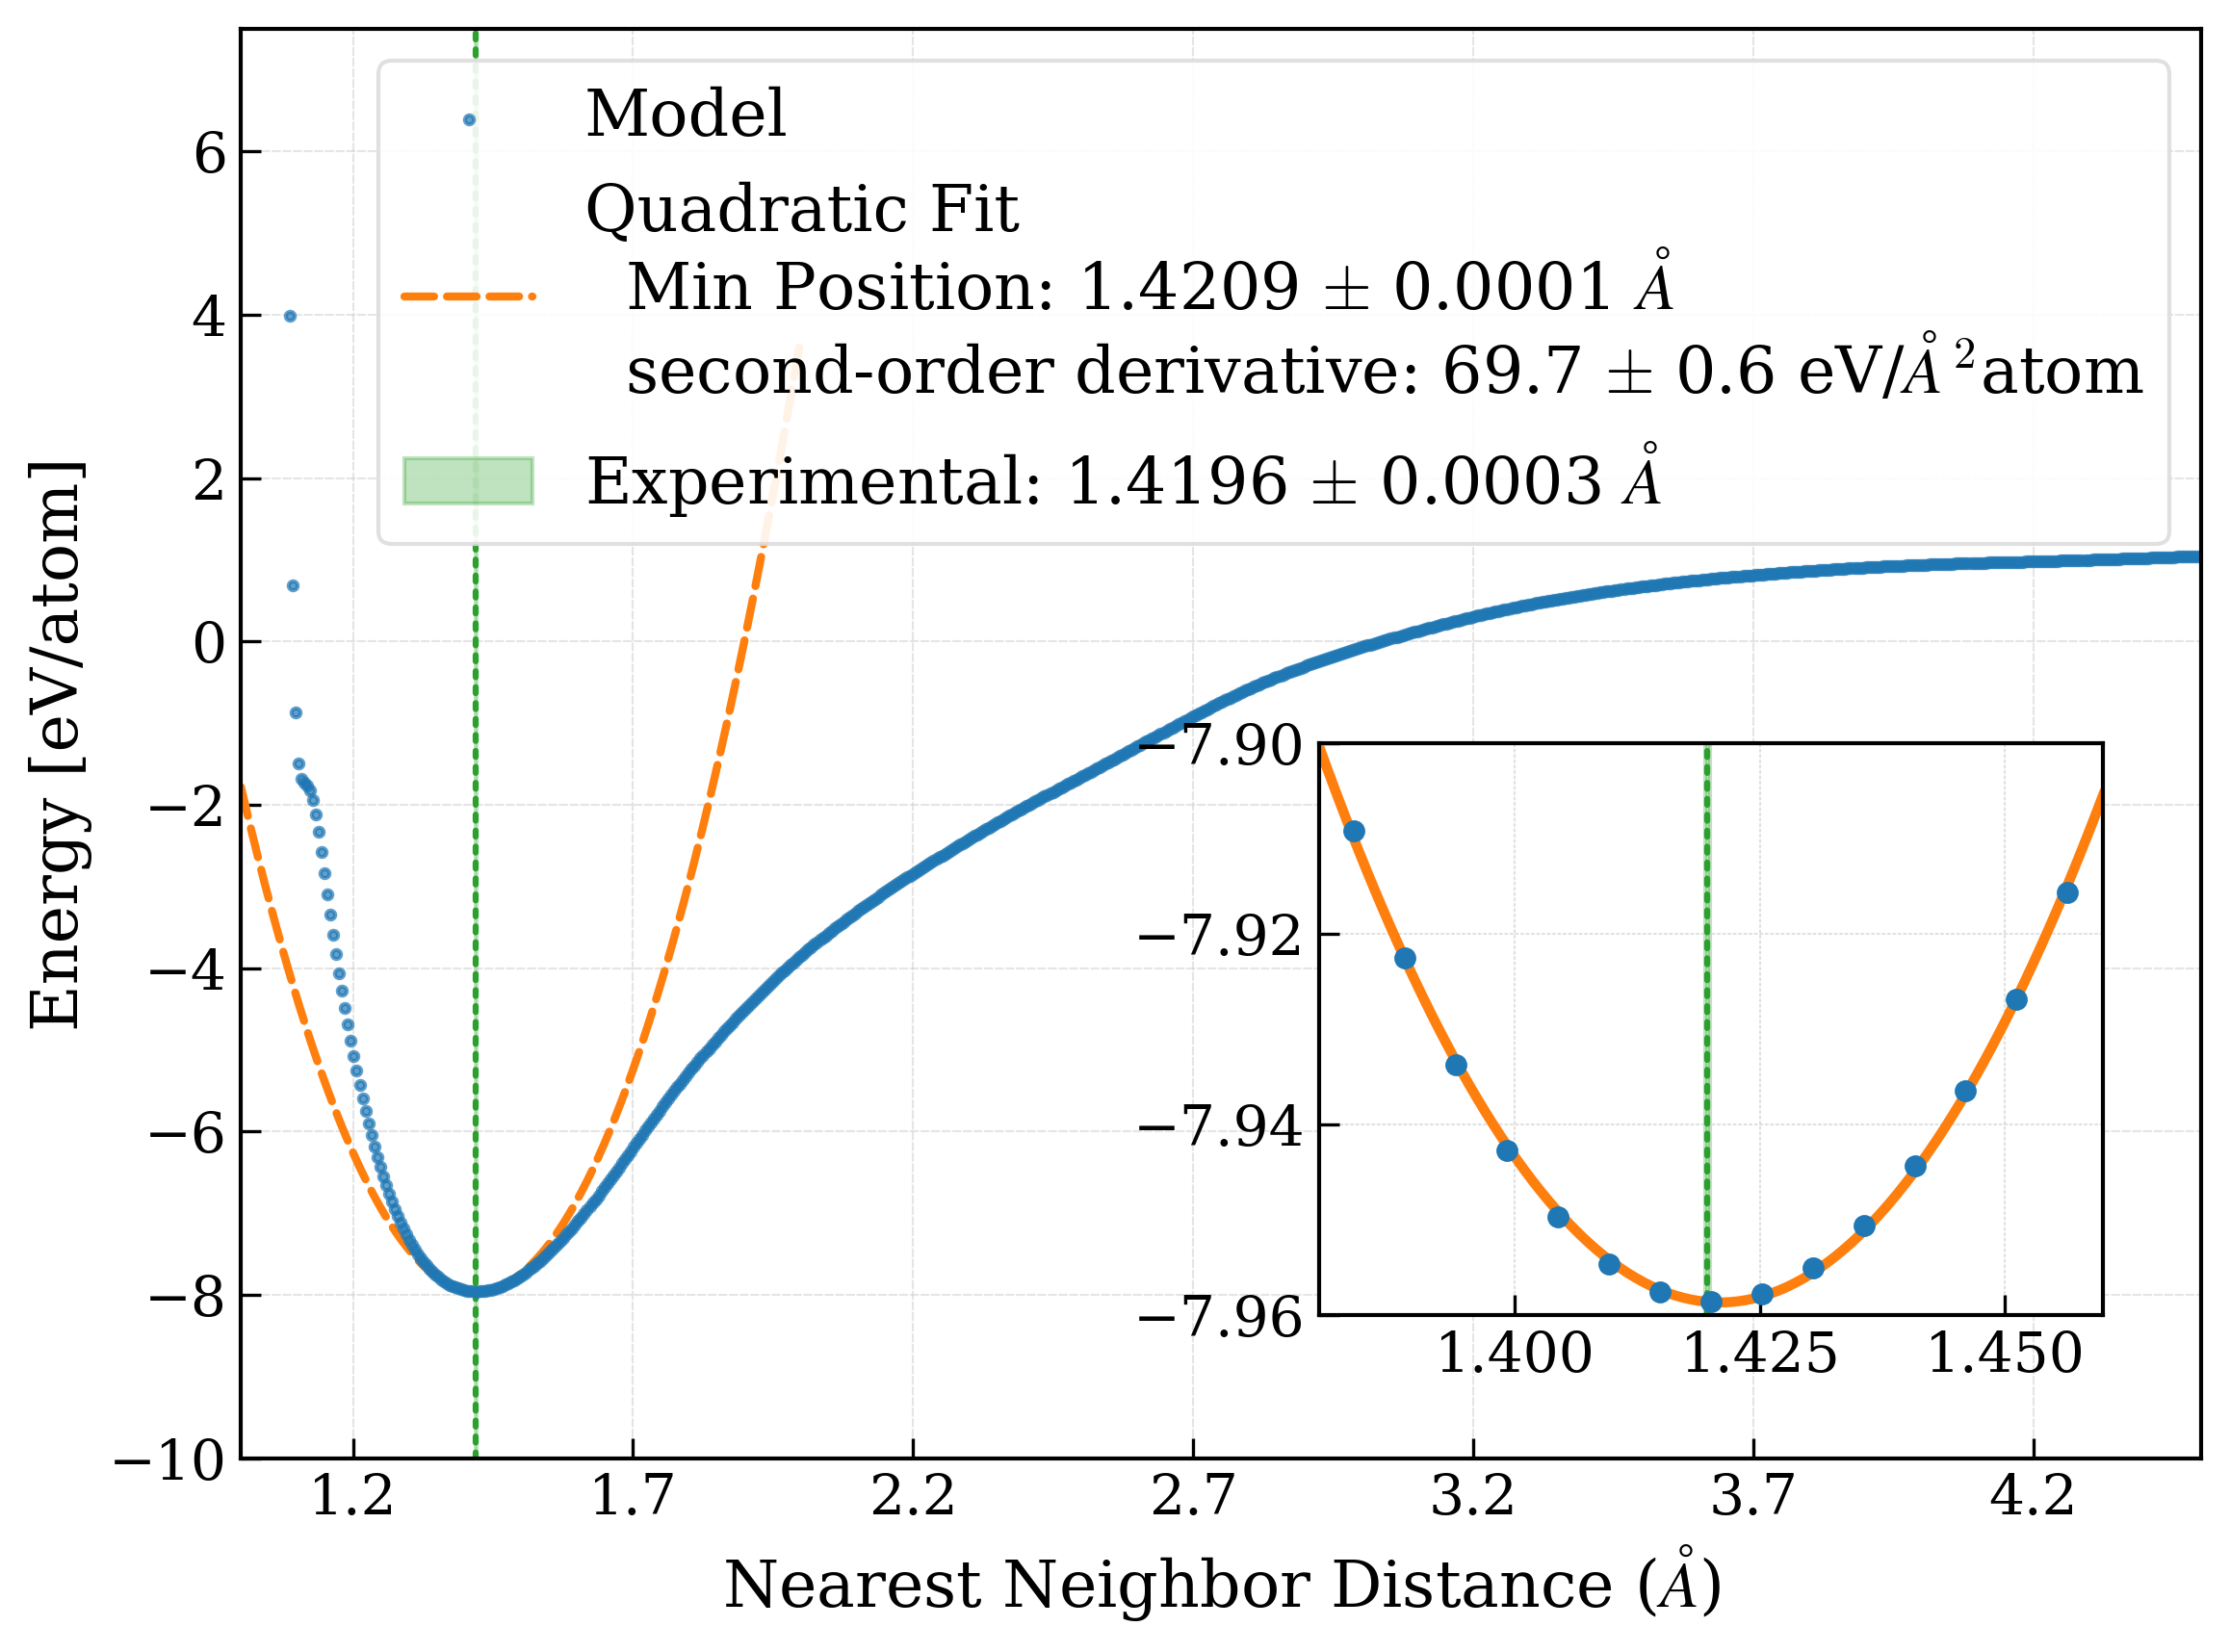

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from numpy import polyfit, poly1d

experimental = 2.4589 / np.sqrt(3)
experimental_uncertainty = 0.0005 / np.sqrt(3)

# Dummy data placeholder — replace with your actual 'data' matrix
# data = np.random.rand(1000, 2) 

# ==========================================
# 1. SETUP & INITIALIZATION
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6))
scale = 1/np.sqrt(3)

# Scale the raw data axes directly for plotting consistency
x_scaled = data[:, 0] * scale
y_scaled = data[:, 1] / 2.0

# FIX: Added rasterized=True to fix the PDF rendering bug, 
# changed edgecolors to 'face', and set zorder=2 to place it on top.
ax.scatter(
    x_scaled, y_scaled, 
    label="Model", 
    color="#1f77b4", 
    alpha=0.7, 
    edgecolors='face', 
    s=5, 
    zorder=2,
    rasterized=True
)

# ==========================================
# 2. DATA FILTERING & POLYNOMIAL FITTING
# ==========================================
# Clean Inset Limits (defined in scaled units)
quadratic_limits = (1.38, 1.46)

# Masking using the scaled X values to target the zoom window
mask = (x_scaled > quadratic_limits[0]) & (x_scaled < quadratic_limits[1])
row_indices = np.where(mask)[0]

x_fit_pts = x_scaled[row_indices]
y_fit_pts = y_scaled[row_indices]

# Fit 2nd-degree polynomial to the scaled data window
# coeffs order: [a, b, c] for ax^2 + bx + c
coeffs, covar = polyfit(x_fit_pts, y_fit_pts, deg=2, cov=True)
poly2 = poly1d(coeffs)

# ==========================================
# 3. DERIVATIVE & MINIMUM CALCULATIONS WITH UNCERTAINTIES
# ==========================================
a, b, c = coeffs

# Extract variances and covariance from the fit matrix
# Indexing maps to [a, b, c]
var_a = covar[0, 0]
var_b = covar[1, 1]
cov_ab = covar[0, 1]

# 1. Minimum Position x_min = -b / (2a)
x_min = -b / (2 * a)
y_min = poly2(x_min)

# Error propagation for x_min: f(a,b) = -b / (2a)
# partial_a = b / (2 * a^2), partial_b = -1 / (2 * a)
df_da = b / (2 * (a ** 2))
df_db = -1 / (2 * a)
x_min_err = np.sqrt((df_da ** 2) * var_a + (df_db ** 2) * var_b + 2 * df_da * df_db * cov_ab)

# 2. Second-order derivative d^2E/dx^2 = 2a
d2E_dx2_scaled = 2 * a  
d2E_dx2_scaled_err = 2 * np.sqrt(var_a) # linear scaling of standard deviation

# 3. Rescaled back relative to the original unscaled data matrix axis
d2E_dx2_raw = d2E_dx2_scaled * (scale ** 2)

# ==========================================
# 4. MAIN PLOT ADDITIONS
# ==========================================
# Generate a wider X range for the main plot parabola
x_wide = np.linspace(1, 2, 200)

fit_label = (
    f"Quadratic Fit\n"
    rf"  Min Position: {x_min:.4f} $\pm$ {x_min_err:.4f} $\AA$"
    "\n"
    rf"  second-order derivative: {d2E_dx2_scaled:.1f} $\pm$ {d2E_dx2_scaled_err:.1f} eV/$\AA^2$atom"
)
# FIX: Set zorder=1 so the line passes underneath the data points
ax.plot(x_wide, poly2(x_wide), color="#ff7f0e", linestyle="--", linewidth=2, label=fit_label, zorder=1)

# --- EXPERIMENTAL VALUE & UNCERTAINTY (MAIN PLOT) ---
exp_low = experimental - experimental_uncertainty
exp_high = experimental + experimental_uncertainty

# Shaded region for uncertainty window
ax.axvspan(
    exp_low, exp_high, 
    color="#2ca02c", 
    alpha=0.3, 
    label=f"Experimental: {experimental:.4f} $\pm$ {experimental_uncertainty:.4f} $\AA$", 
    zorder=0
)
# Central vertical indicator line
ax.axvline(experimental, color="#2ca02c", linestyle=":", linewidth=1.5, zorder=1)

# ==========================================
# 5. INSET SETUP & ZOOM
# ==========================================
axins = ax.inset_axes([0.55, 0.1, 0.4, 0.4]) 

# FIX: Added rasterized=True and zorder=2 to mirror the main axes fixes
axins.scatter(
    x_scaled, y_scaled, 
    color="#1f77b4", 
    s=20, 
    edgecolors='face',
    zorder=2,
    rasterized=True
)

# Plot the fitted parabola segment tightly inside the inset
x_ins_fit = np.linspace(quadratic_limits[0], quadratic_limits[1], 100)
# FIX: Set zorder=1 for the inset line
axins.plot(x_ins_fit, poly2(x_ins_fit), color="#ff7f0e", linewidth=2.5, zorder=1)

# --- EXPERIMENTAL VALUE & UNCERTAINTY (INSET) ---
# If experimental value is within the inset bounds, shade it normally
if quadratic_limits[0] <= experimental <= quadratic_limits[1]:
    axins.axvspan(exp_low, exp_high, color="#2ca02c", alpha=0.3, zorder=0)
    axins.axvline(experimental, color="#2ca02c", linestyle=":", linewidth=1.5, zorder=1)
else:
    # If it is out of bounds (like 1.92 \AA), add an indicator showing which direction it is
    if experimental > quadratic_limits[1]:
        axins.axvline(quadratic_limits[1], color="#2ca02c", linestyle="-.", alpha=0.5, zorder=1)
        axins.annotate("", xy=(1.455, -7.93), xytext=(1.44, -7.93),
                       arrowprops=dict(arrowstyle="->", color="#2ca02c", lw=1.5))
        axins.text(1.45, -7.925, "Exp. $\\rightarrow$", color="#2ca02c", fontsize=9, ha='right')
    elif experimental < quadratic_limits[0]:
        axins.axvline(quadratic_limits[0], color="#2ca02c", linestyle="-.", alpha=0.5, zorder=1)
        axins.annotate("", xy=(1.385, -7.93), xytext=(1.40, -7.93),
                       arrowprops=dict(arrowstyle="->", color="#2ca02c", lw=1.5))
        axins.text(1.39, -7.925, "$\\leftarrow$ Exp.", color="#2ca02c", fontsize=9, ha='left')

# Set tight bounds on the inset to look directly at the valley minimum
axins.set_xlim(quadratic_limits) 
axins.set_ylim(-7.96, -7.9)
axins.grid(True, linestyle=":", alpha=0.6)

# Draw the connector lines from the main plot box to the inset axes
# ax.indicate_inset_zoom(axins, edgecolor="gray", alpha=0.5)

# ==========================================
# 6. GLOBAL FORMATTING & EXPORT
# ==========================================
ax.set_xlabel("Nearest Neighbor Distance ($\AA$)")
ax.set_ylabel("Energy [eV/atom]")
ax.set_ylim(-10, 7.5)
ax.set_xlim(1, 4.5)
ax.set_xticks(np.arange(1.2, 4.6, 0.5))

ax.legend(loc="upper right", framealpha=0.9)
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("BM_graphene_lp_scan.pdf", bbox_inches="tight")
plt.show()

In [13]:
x_scaled

array([0.57735027, 0.58255162, 0.58775298, 0.59295433, 0.59815568,
       0.60335704, 0.60855839, 0.61375975, 0.6189611 , 0.62416245,
       0.62936381, 0.63456516, 0.63976651, 0.64496787, 0.65016922,
       0.65537058, 0.66057193, 0.66577328, 0.67097464, 0.67617599,
       0.68137734, 0.6865787 , 0.69178005, 0.69698141, 0.70218276,
       0.70738411, 0.71258547, 0.71778682, 0.72298817, 0.72818953,
       0.73339088, 0.73859224, 0.74379359, 0.74899494, 0.7541963 ,
       0.75939765, 0.76459901, 0.76980036, 0.77500171, 0.78020307,
       0.78540442, 0.79060577, 0.79580713, 0.80100848, 0.80620984,
       0.81141119, 0.81661254, 0.8218139 , 0.82701525, 0.8322166 ,
       0.83741796, 0.84261931, 0.84782067, 0.85302202, 0.85822337,
       0.86342473, 0.86862608, 0.87382743, 0.87902879, 0.88423014,
       0.8894315 , 0.89463285, 0.8998342 , 0.90503556, 0.91023691,
       0.91543826, 0.92063962, 0.92584097, 0.93104233, 0.93624368,
       0.94144503, 0.94664639, 0.95184774, 0.95704909, 0.96225

In [14]:
y_scaled

array([ 1.64267008e+09,  1.24867610e+09,  9.47234688e+08,  7.17320832e+08,
        5.42433344e+08,  4.09711232e+08,  3.09186176e+08,  2.33169664e+08,
        1.75763824e+08,  1.32457376e+08,  9.98143200e+07,  7.52227040e+07,
        5.67017800e+07,  4.27538240e+07,  3.22472980e+07,  2.43301600e+07,
        1.83610080e+07,  1.38577800e+07,  1.04580660e+07,  7.88961900e+06,
        5.94787400e+06,  4.47907600e+06,  3.38979800e+06,  2.59982875e+06,
        1.98835812e+06,  1.52941800e+06,  1.17849425e+06,  9.04051062e+05,
        6.89856000e+05,  5.23108656e+05,  3.93669562e+05,  2.93537906e+05,
        2.16397188e+05,  1.57259812e+05,  1.12192789e+05,  7.80961953e+04,
        5.25252500e+04,  3.35539453e+04,  2.06201523e+04,  1.13058018e+04,
        4.51235742e+03, -3.34250854e+02, -3.68874268e+03, -5.90984375e+03,
       -7.27896680e+03, -8.01667676e+03, -8.00792969e+03, -7.26835547e+03,
       -6.48170020e+03, -5.69480176e+03, -4.84470117e+03, -4.07279932e+03,
       -3.37023169e+03, -

<>:4: SyntaxWarning: invalid escape sequence '\A'
<>:4: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_127300/3103567937.py:4: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel("Nearest Neighbor Distance ($\AA$)")


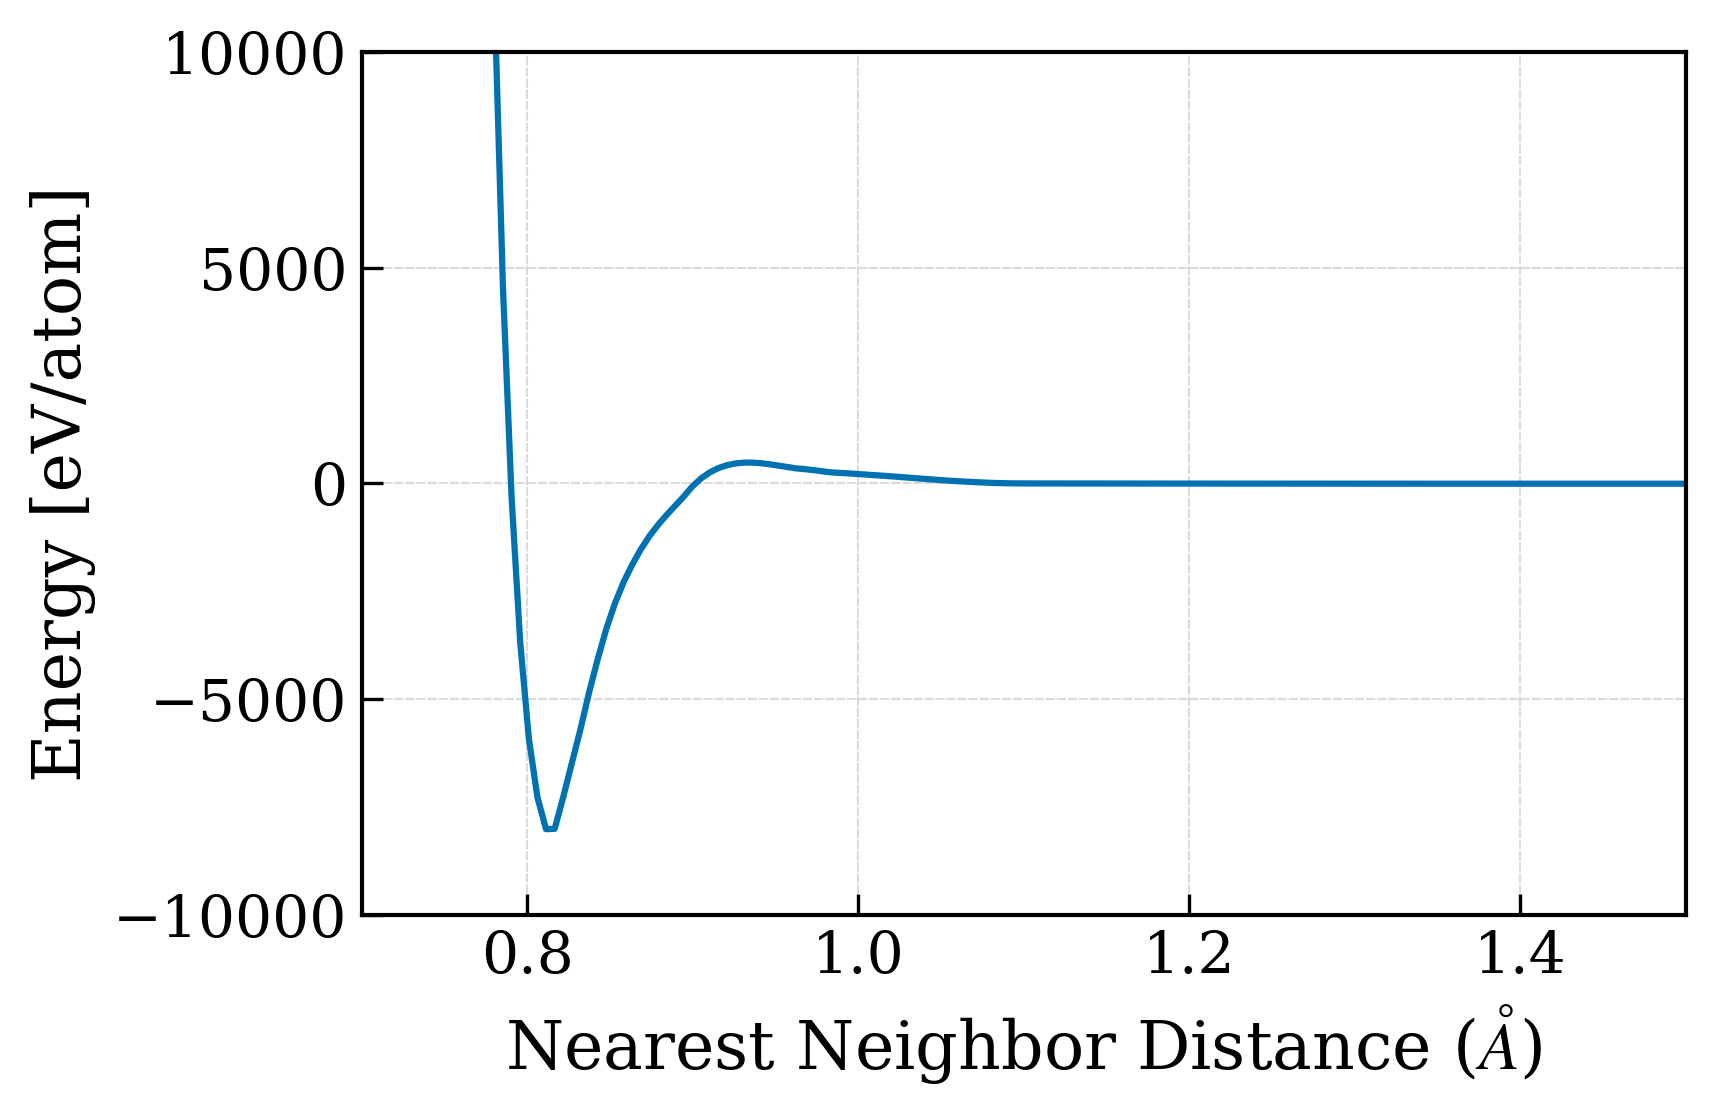

In [15]:
plt.plot(x_scaled, y_scaled)
plt.ylim(-1e4, 1e4)
plt.xlim(0.7, 1.5)
plt.xlabel("Nearest Neighbor Distance ($\AA$)")
plt.ylabel("Energy [eV/atom]")
plt.savefig("BM_graphene_lp_problematic.pdf")

In [16]:
from scipy.constants import elementary_charge, Boltzmann

In [17]:
(400 * elementary_charge) / Boltzmann

4641807.248620032